# Preprocessing pipelines

Transforms are used to preprocess or augment an input point cloud. They are designed as atomic operations for easier composition.
Each transform expects a single-scene `dict` containing specific keys -- see the [Transform gallery](../transforms/overview.md) for details of what each transform expects.

This notebook will guide you on how to manipulate point clouds and preprocess them using this API.

## Setup

In [1]:
# On Colab:
# !pip install "torch-pointcloud[pyg-lib]"

In [2]:
import torch

import torch_pointcloud as tp

torch.manual_seed(0)
print("torch-pointcloud", tp.__version__)

torch-pointcloud 0.1.0


## Utils

Let's define a few utils to help us visualize the point clouds.

In [3]:
import matplotlib.pyplot as plt


def show_cloud(pos, color=None, *, ax=None, title=None, size=6, cmap="viridis"):
    """Scatter a point cloud. `pos` is (N, 3); `color` is per-point RGB, a label vector, or None."""
    if ax is None:
        ax = plt.figure(figsize=(4, 4)).add_subplot(projection="3d")

    p = pos.detach().cpu().numpy()
    c = color.detach().cpu().numpy() if torch.is_tensor(color) else color
    kw = {} if c is None else {"cmap": cmap}
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax

## Input point cloud

We use the standard keys: `pos` for $(N, 3)$ coordinates and `color` for $(N, 3)$ RGB. Here is a synthetic "wall + floor" scene with a color gradient, so transforms are easy to see.

In [4]:
n = 8000
floor = torch.rand(n // 2, 3) * torch.tensor([4.0, 4.0, 0.05])
wall = torch.rand(n // 2, 3) * torch.tensor([4.0, 0.05, 2.5])
pos = torch.cat([floor, wall])
color = (pos - pos.min(0).values) / (pos.max(0).values - pos.min(0).values)  # position -> RGB

scene = {"pos": pos, "color": color}
{k: tuple(v.shape) for k, v in scene.items()}

{'pos': (8000, 3), 'color': (8000, 3)}

/tmp/ipykernel_454041/3321240126.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)


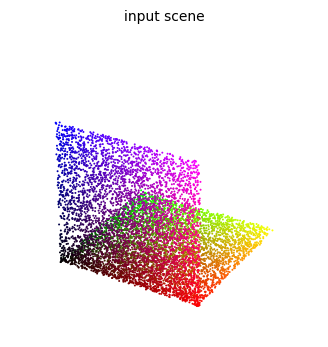

In [5]:
show_cloud(scene["pos"], color=scene["color"], title="input scene", size=2);

`show_cloud` reads an $(N, 3)$ `color` as per-point RGB: the wall stands at $y \approx 0$ and the floor runs away from it, and the gradient makes both easy to follow through a transform.

## One transform at a time

A transform is constructed with the `keys` it acts on, then called on the dict. It returns a **new** dict; keys it does not touch pass through untouched. `Rescale(method="centroid")` centers the cloud and scales it into the unit sphere:

In [7]:
import torch_pointcloud.transforms as T

rescaled = T.Rescale(keys="pos", method="centroid")(scene)

print("input  center / radius:", scene["pos"].mean(0).round(decimals=2).tolist(), "/", round(scene["pos"].norm(dim=1).max().item(), 2))
print("output center / radius:", rescaled["pos"].mean(0).round(decimals=2).tolist(), "/", round(rescaled["pos"].norm(dim=1).max().item(), 2))
print("color untouched:", torch.equal(rescaled["color"], scene["color"]))

input  center / radius: [2.0299999713897705, 1.0, 0.6399999856948853] / 5.64
output center / radius: [0.0, 0.0, -0.0] / 1.0
color untouched: True


![A room point cloud before and after Rescale(method="centroid"), the second one centered and much smaller.](../assets/transforms/rescale_centroid_scene.png)

`Rescale` moves the centroid to the origin and divides by the largest distance from it, so the output always sits in the unit sphere: on this scene the center goes from $(2.03, 1.00, 0.64)$ to the origin and the radius from 5.64 to 1.0. That puts scenes of different sizes on one scale. The shape itself does not change, which is why both panels above are drawn in the same box.

When several keys are passed together, they stay in correspondence. `RandomSample` draws the same indices for every listed key, so `pos` and `color` shrink to the same 2048 rows:

In [8]:
sampled = T.RandomSample(keys=("pos", "color"), num_samples=2048)(rescaled)
{k: tuple(v.shape) for k, v in sampled.items()}

{'pos': (2048, 3), 'color': (2048, 3)}

## Augmentations

Augmentations are random and take a probability `p`. With `p=1.0` they always fire. Below we show a 30 degrees rotation about the vertical axis, then a color jitter. Color transforms act on the `color` key and expect $[0, 1]$ floats by default (pass `int_color=True` for $[0, 255]$):

/tmp/ipykernel_454041/3321240126.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)


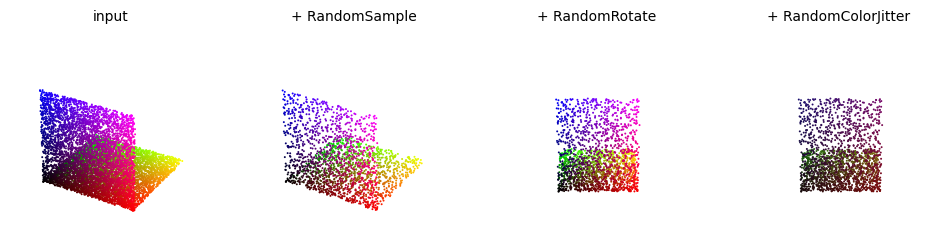

In [9]:
rotated = T.RandomRotate(keys="pos", angle_range=(30.0, 30.0), axis=2, p=1.0)(sampled)
jittered = T.RandomColorJitter(keys="color", brightness=0.5, contrast=0.5, saturation=0.5, p=1.0)(rotated)

steps = {
    "input": scene,
    "+ RandomSample": sampled,
    "+ RandomRotate": rotated,
    "+ RandomColorJitter": jittered,
}
fig = plt.figure(figsize=(12, 3.2))
for i, (title, step) in enumerate(steps.items()):
    show_cloud(step["pos"], color=step["color"], ax=fig.add_subplot(1, 4, i + 1, projection="3d"), title=title, size=2)

![augmentations](../assets/tutorials/transforms_pipeline_steps.png)

## Compose a pipeline

`Compose` chains transforms into one callable. A typical training pipeline normalizes geometry, subsamples to a fixed budget, then augments:

In [11]:
train_transform = T.Compose([
    T.Rescale(keys="pos", method="centroid"),
    T.RandomSample(keys=("pos", "color"), num_samples=2048),
    T.RandomFlip(keys="pos", axes=[0, 1], p=0.5),
    T.RandomScale(keys="pos", scale_range=(0.9, 1.1)),
    T.RandomJitter(keys="pos", sigma=0.01, clip=0.05),
])

out = train_transform({"pos": pos.clone(), "color": color.clone()})
{k: tuple(v.shape) for k, v in out.items()}

{'pos': (2048, 3), 'color': (2048, 3)}

At evaluation you keep the deterministic steps and drop the random ones, so results are reproducible:

In [12]:
val_transform = T.Compose([
    T.Rescale(keys="pos", method="centroid"),
    T.RandomSample(keys=("pos", "color"), num_samples=2048),
])
tuple(val_transform({"pos": pos.clone(), "color": color.clone()})["pos"].shape)

(2048, 3)

The evaluation pipeline returns the same scene every time; the training one returns a different draw on every call. Run the two side by side, three consecutive draws against one evaluation pass:

eval pipeline: radius 0.99
train pipeline, draw 1: radius 0.98
train pipeline, draw 2: radius 0.89
train pipeline, draw 3: radius 0.91


/tmp/ipykernel_454041/3321240126.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)


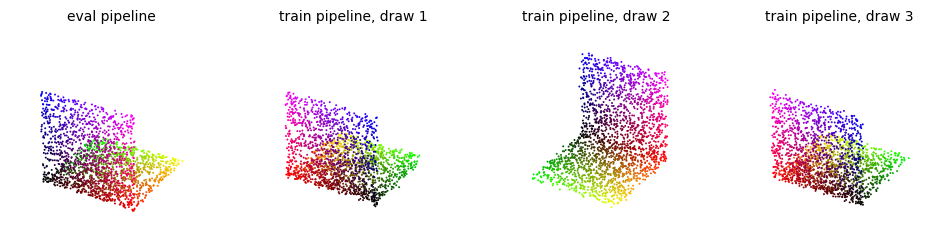

In [13]:
torch.manual_seed(1)
draws = {"eval pipeline": val_transform({"pos": pos.clone(), "color": color.clone()})}
for i in (1, 2, 3):
    draws[f"train pipeline, draw {i}"] = train_transform({"pos": pos.clone(), "color": color.clone()})

for name, draw in draws.items():
    print(f"{name}: radius {draw['pos'].norm(dim=1).max():.2f}")

fig = plt.figure(figsize=(12, 3.2))
for i, (title, draw) in enumerate(draws.items()):
    show_cloud(draw["pos"], color=draw["color"], ax=fig.add_subplot(1, 4, i + 1, projection="3d"), title=title, size=2)

![One panel of the evaluation pipeline output beside three draws of the training pipeline, each mirrored a different way.](../assets/tutorials/transforms_train_vs_eval.png)

The evaluation panel is the scene as it stands, subsampled and nothing more, and it comes back identical on every call. Follow the color gradient across the other three: `RandomFlip` fires on all of them, mirroring about $x$ in the first and third draw and about $y$ in the second. `RandomScale` is the change the picture does not show, because each panel is framed to its own data; the printed radii are where it shows up, 0.98, 0.89 and 0.91 against the 0.99 of the evaluation pass. That variety is what the training pipeline is for: the model never sees the same scene twice.

## Reproducibility

Random transforms accept a `torch.Generator`, so a pipeline can be made deterministic without touching the global RNG. Two draws from the same seed match:

In [14]:
g1 = torch.Generator().manual_seed(42)
g2 = torch.Generator().manual_seed(42)
a = T.RandomSample(keys="pos", num_samples=512, generator=g1)({"pos": pos.clone()})["pos"]
b = T.RandomSample(keys="pos", num_samples=512, generator=g2)({"pos": pos.clone()})["pos"]
print("identical draws:", torch.equal(a, b))

identical draws: True


## The functional layer

If you already hold a tensor and do not want a dict, call the functions in `torch_pointcloud.transforms.functional` directly. They are the same operations the class transforms wrap.

In [15]:
import torch_pointcloud.transforms.functional as F

p = torch.randn(1000, 3)
p = F.shift(p, method="bbox", axes=[0, 1])  # center X and Y on the bbox midpoint
p = F.shift(p, method="min", axes=[2])       # drop Z so the floor sits at 0
mask = F.sphere_mask(p, center=[0.0, 0.0, 0.0], radius=2.0)
print("shifted:", tuple(p.shape), "| kept by sphere mask:", int(mask.sum()))

shifted: (1000, 3) | kept by sphere mask: 62
